# Saint Petersburg Real Estate Analysis

This project uses data from Yandex Real Estate, an archive of apartment sale listings in Saint Petersburg and nearby localities collected over several years. The objective is to identify the factors that determine market value by conducting exploratory data analysis of residential properties. The findings may support the future development of an automated system for detecting anomalous or potentially fraudulent listings.

Each listing contains two types of information. The first is user-provided data, while the second is generated automatically from cartographic and geospatial sources. For example, distances to the city center, the airport, and other points of interest are computed automatically. The number of nearby parks and bodies of water is likewise derived without direct user input.

**Research Objectives**

1. Examine the structure and quality of the real estate dataset.
2. Identify the principal factors associated with property prices.
3. Assess how apartment prices vary with key property characteristics.
4. Evaluate the influence of location and listing publication time, including day of week, month, and year.
5. Develop an evidence-based view of the residential real estate market represented in the data.
6. Produce findings that may support the development of automated anomaly and fraud detection tools.

**Research Design**

The analysis proceeds through several stages: initial data inspection, preprocessing, feature engineering, and detailed examination of the factors associated with price formation. At the outset, the quality of the source file `"/datasets/real_estate_data.csv"` is unknown. Accordingly, the first step is to assess the dataset, identify data quality issues, and evaluate their potential effect on subsequent results. The identified issues are then addressed to reduce bias and improve the reliability of the conclusions.

Additional analytical variables are subsequently constructed, including price per square meter, temporal features, and floor-type categories, to support deeper exploratory analysis.

The study is organized into seven stages:

- **Data overview**: inspection of the raw dataset and identification of data quality issues.
- **Data preprocessing**: correction of errors and treatment of missing values where appropriate.
- **Feature engineering**: creation of additional analytical variables, such as price per square meter and floor type.
- **Leningrad region analysis**: examination of real estate characteristics across the Leningrad region.
- **Saint Petersburg analysis**: examination of real estate characteristics within Saint Petersburg.
- **Comparison of price drivers**: assessment of whether the determinants of price differ across locations.
- **Final conclusion**: synthesis of the main findings and key market patterns.

### Loading and Initial File Overview

In [1]:
import os
import pandas as pd 

import matplotlib.pyplot as plt  # Import libraries for visualization
import numpy as np
import seaborn as sns

from pathlib import Path

IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

def save_plot(name: str, dpi: int = 300):
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Saved: {IMG_DIR / f'{name}.png'}")


In [2]:
data_path = next(Path("..").glob("**/real_estate_data.csv"), None)

if data_path is not None:
    data = pd.read_csv(data_path, sep="\t")
    print(f"Data loaded from: {data_path}")
else:
    raise FileNotFoundError("real_estate_data.csv not found")

Data loaded from: ../data/real_estate_data.csv


In [3]:
data.head(10)  # Display the first rows of the dataset
data.info()    # Show general information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

- **23,699 rows and 22 columns**: the dataset is sufficiently large for exploratory analysis.  
- **Missing-data issues**:  
	- `ceiling_height` contains approximately **9,200 missing values**.  
	- `living_area`, `kitchen_area`, `balcony`, `is_apartment`, `airports_nearest`, and several other variables are also incomplete.  
- **Data types**:  
	- `first_day_exposition` is stored as `object`, although it should be converted to `datetime`.  
	- The remaining data types appear broadly appropriate for analysis.

Saved: ../images/numeric_features_histograms.png


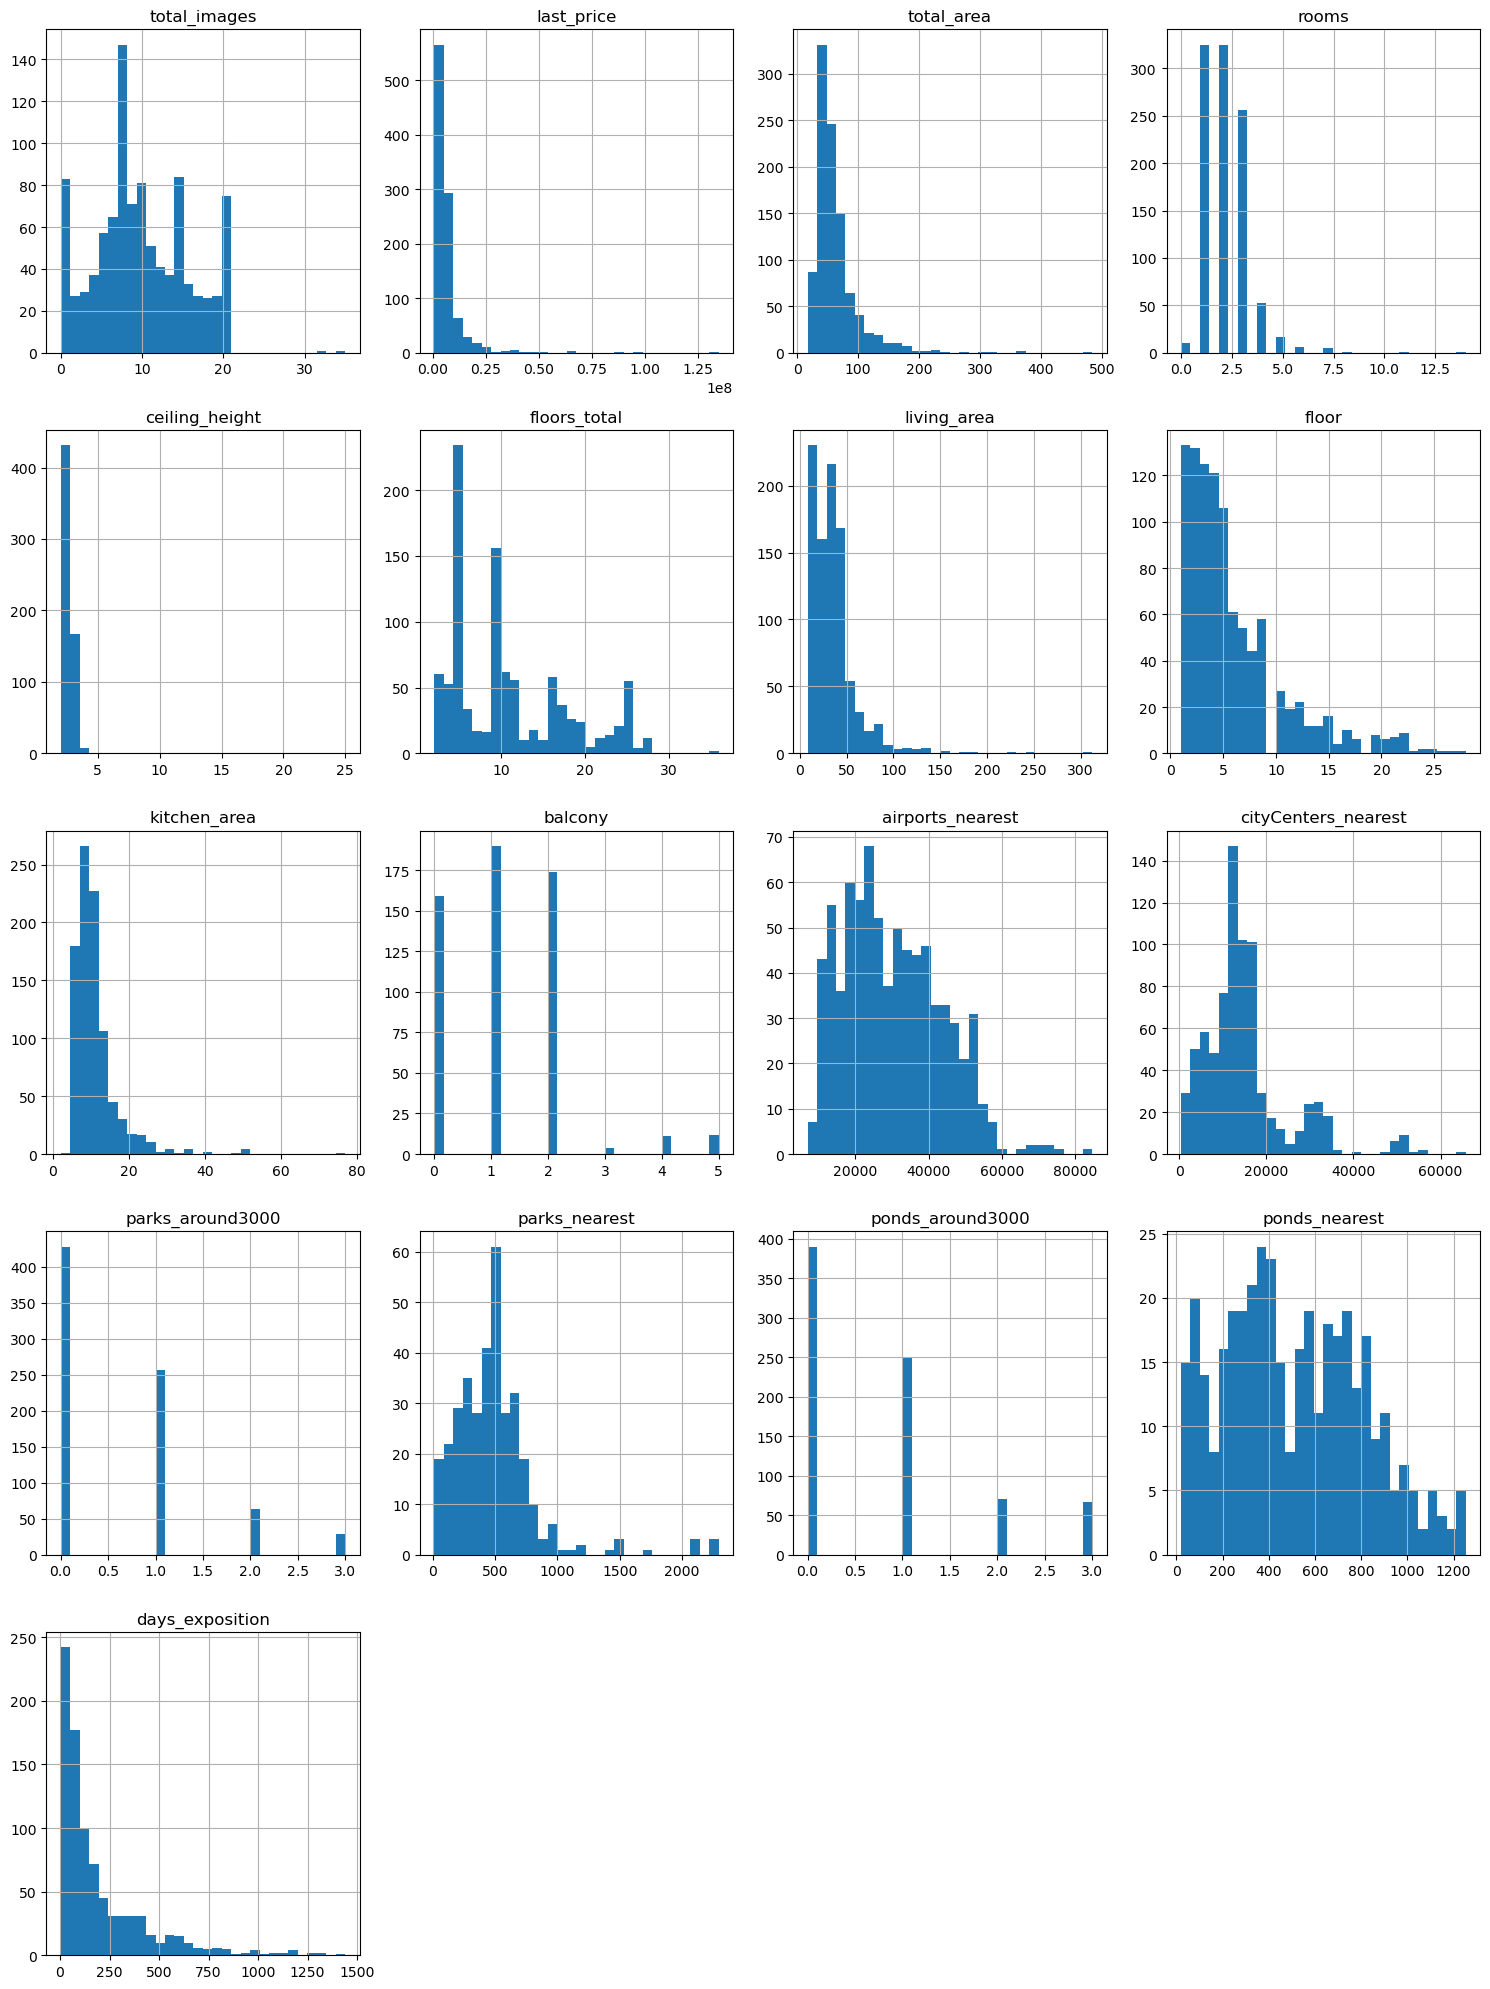

In [4]:
data[:1000].hist(figsize=(15, 20), bins=30)
plt.tight_layout()  # Automatically adjusts subplot spacing to prevent overlap
save_plot("numeric_features_histograms")
plt.show()  # Build histograms for all numeric features to understand distributions


#### Data Loading and Initial Exploration

**Procedure:**

- Loaded the dataset from the source file.
- Reviewed the first rows and inspected the dataset structure using `.info()` and `.describe()`.
- Plotted histograms for the numerical variables.

**Preliminary conclusion:**

The dataset comprises 22 columns and 23,699 observations. It contains numerical, boolean, and string variables. Several columns include substantial missingness, most notably `ceiling_height`, `living_area`, and `is_apartment`. In addition, some values appear anomalous, including extremely low and extremely high property prices.

### Data Preprocessing

#### Handling Missing Values

Several variables contain missing values. These are addressed either through imputation, where a defensible rule can be applied, or left unchanged where replacement would be unjustified.

##### Filling in missing values for numeric columns

In [5]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())
data['living_area'] = data['living_area'].fillna(data['living_area'].median())  
data['kitchen_area'] = data['kitchen_area'].fillna(0)  # If kitchen area is not specified, assume it is 0
data['balcony'] = data['balcony'].fillna(0)  # If balcony is not specified, assume it is 0


Observations for which `floor` is recorded but `floors_total` is missing are removed, since this variable cannot be imputed reliably using a generic statistic such as the median. Remaining missing values in `floors_total` are then imputed with the median.

In [6]:
data = data[~((data['floor'].notna()) & (data['floors_total'].isna()))]  # Remove rows where 'floor' is present but 'floors_total' is missing
data['floors_total'] = data['floors_total'].fillna(data['floors_total'].median())  # Fill missing values with median
data['parks_around3000'] = data['parks_around3000'].fillna(data['parks_around3000'].median())
data['ponds_around3000'] = data['ponds_around3000'].fillna(data['ponds_around3000'].median())
data['parks_nearest'] = data['parks_nearest'].fillna(data['parks_nearest'].median())  # Fill missing values with median
data['ponds_nearest'] = data['ponds_nearest'].fillna(data['ponds_nearest'].median())  # Fill missing values with median
data['days_exposition'] = data['days_exposition'].fillna(data['days_exposition'].median())  # Fill missing values with median

##### Filling Missing Values in String Columns

In [7]:
data['locality_name'] = data['locality_name'].fillna('Unknown')
data['is_apartment'] = data['is_apartment'].fillna('Unknown')

##### Missing values in distance-related columns (for example, distance to the airport or city center)

In [8]:
data['airports_nearest'] = data['airports_nearest'].fillna(data['airports_nearest'].median())
data['cityCenters_nearest'] = data['cityCenters_nearest'].fillna(data['cityCenters_nearest'].median())
data.isnull().sum() # Check for remaining missing values after filling
data['last_price'].describe()

count    2.361300e+04
mean     6.540555e+06
std      1.090172e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64

The minimum recorded price, **12,190**, is implausibly low for a residential property and is therefore likely to reflect a data-entry error, such as an incorrect unit or currency.

The maximum recorded price, **763,000,000**, appears to be an extreme outlier relative to the remainder of the distribution.

To reduce the influence of such extreme values, the lower and upper bounds for outlier filtering are set at the **1st** and **99th percentiles** of the price distribution. This approach excludes observations most likely to distort the analysis while preserving the overwhelming majority of listings and improving the representativeness of the results.

In [9]:
# Calculate the 1st and 99th percentiles of the 'last_price' column to identify outliers
lower_bound = data['last_price'].quantile(0.01)
upper_bound = data['last_price'].quantile(0.99)

# Keep only the rows where the price is within the 1st-99th percentile range (inclusive)
data_no_outliers = data[(data['last_price'] >= lower_bound) & (data['last_price'] <= upper_bound)].copy()
data['last_price'].describe()

count    2.361300e+04
mean     6.540555e+06
std      1.090172e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64

- **Minimum price:** 1,010,000, which is considerably more plausible than the original minimum value of 12,190.  
- **Maximum price:** 35,953,000, still relatively high but no longer as extreme as 763,000,000.  
- **Average price:** 5,885,585, which provides a more representative estimate after outlier removal.  
- **Median price:** 4,650,000, unchanged from the original distribution, indicating that 50% of properties are priced below this level.  
- **Interquartile range:** most observations now fall within a more moderate interval, approximately between 3,450,000 and 6,700,000.

#### Data Type Conversion:

The `first_day_exposition` column is currently stored as `object`, although it clearly represents a date field. Accordingly, it should be converted to the `datetime` type.

In [10]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'])  # Convert the date column to datetime format
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23613 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23613 non-null  int64         
 1   last_price            23613 non-null  float64       
 2   total_area            23613 non-null  float64       
 3   first_day_exposition  23613 non-null  datetime64[ns]
 4   rooms                 23613 non-null  int64         
 5   ceiling_height        23613 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23613 non-null  float64       
 8   floor                 23613 non-null  int64         
 9   is_apartment          23613 non-null  object        
 10  studio                23613 non-null  bool          
 11  open_plan             23613 non-null  bool          
 12  kitchen_area          23613 non-null  float64       
 13  balcony              

The `balcony` variable is converted to a boolean type to indicate the presence or absence of a balcony. The `bool` type is preferable to `int` in this context because it improves interpretability, simplifies filtering and feature construction, and is more memory-efficient.

In [11]:
data['balcony'] = data['balcony'].notna()  # True if a balcony is present, False otherwise
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23613 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23613 non-null  int64         
 1   last_price            23613 non-null  float64       
 2   total_area            23613 non-null  float64       
 3   first_day_exposition  23613 non-null  datetime64[ns]
 4   rooms                 23613 non-null  int64         
 5   ceiling_height        23613 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23613 non-null  float64       
 8   floor                 23613 non-null  int64         
 9   is_apartment          23613 non-null  object        
 10  studio                23613 non-null  bool          
 11  open_plan             23613 non-null  bool          
 12  kitchen_area          23613 non-null  float64       
 13  balcony              

The data is now ready for time-based analysis.

#### Removing or Standardizing Implicit Duplicates

In [12]:
# Standardize locality names
data['locality_name'] = (
    data['locality_name']
    .str.replace('поселок', 'посёлок', regex=False)
    .str.replace('городской посёлок', 'посёлок', regex=False)
    .str.replace('посёлок городского типа', 'посёлок', regex=False)
    .str.replace('коттеджный посёлок', 'посёлок', regex=False)
    .str.replace('посёлок при железнодорожной станции', 'посёлок станции', regex=False)
    .str.strip()
)
data.describe()
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'посёлок Красный Бор', 'Гатчина', 'деревня Фёдоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'посёлок Металлострой', 'посёлок Лебяжье', 'посёлок Сиверский',
       'посёлок Молодцово', 'посёлок Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'посёлок Ефимовский', 'посёлок Плодовое', 'деревня Заклинье',
       'посёлок Торковичи', 'посёлок Первомайское', 'Красное Село',
       'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'посёлок Новый Свет', 'Сланцы',
       'село Путилово', 'Ивангород', 'Мурино', 'Шлиссельбург',
       'Никольское', 'Зелено

In [13]:
# Check for and remove duplicate rows
duplicates = data.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
data = data.drop_duplicates()

Number of duplicates: 0


#### Handling Missing Values

**Procedure:**

- Numerical variables were imputed using either the median or zero, depending on the substantive meaning of the variable.
- Missing string values were replaced with `Unknown`.
- Missing distances to the airport and the city center were imputed with the median.

**Conclusion:**
The principal missing-value issues were addressed, and the dataset is now suitable for further analysis.

#### Type Conversion

**Procedure:**

- Converted `first_day_exposition` from `object` to `datetime`.
- Converted `balcony` from `float64` to `bool`.

**Conclusion:**
These transformations make it possible to extract calendar-based features such as day of week, month, and year, thereby supporting temporal analysis of seasonality and broader market dynamics.

#### Duplicate Handling

**Procedure:**

- Standardized inconsistent locality names to reduce implicit duplication.
- Checked the dataset for explicit duplicate rows.

**Conclusion:**
These steps improve the reliability of grouping by locality and strengthen the validity of the geographic analysis.

### Add New Columns to the Table

#### Price per Square Meter

This variable is calculated by dividing the listing price (`last_price`) by the total area (`total_area`).

In [14]:
data['price_per_m2'] = (data['last_price'] / data['total_area']).round(2)  # Price per square meter

#### Day of Publication

The `first_day_exposition` variable is used to derive the day of the week on which the listing was published.

In [15]:
data['day_of_week'] = data['first_day_exposition'].dt.dayofweek  # Day of publication (0 = Monday, 1 = Tuesday, etc.)

#### Month and Year of Publication

The same date field is also used to derive the month and year of publication.

In [16]:
data['year_month'] = data['first_day_exposition'].dt.to_period('M')  # Publication month (Period)
data['year'] = data['first_day_exposition'].dt.year  # Publication year

#### Floor Category

Each apartment is classified as `first`, `last`, or `other` according to its floor position within the building.

In [17]:
data['floor_type'] = data.apply(
    lambda row: 'first' if row['floor'] == 1 else (
        'last' if row['floor'] == row['floors_total'] else 'other'),
    axis=1
)

#### Distance to the City Center in Kilometers

The `cityCenters_nearest` variable is converted from meters to kilometers to improve interpretability.

In [18]:
data['distance_to_center_km'] = (data['cityCenters_nearest'] / 1000).round()
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,day_of_week,year_month,year,floor_type,distance_to_center_km
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.00,8,Unknown,...,482.0,2.0,755.0,95.0,120370.37,3,2019-03,2019,other,16.0
1,7,3350000.0,40.40,2018-12-04,1,2.65,11.0,18.60,1,Unknown,...,455.0,0.0,503.0,81.0,82920.79,1,2018-12,2018,first,19.0
2,10,5196000.0,56.00,2015-08-20,2,2.65,5.0,34.30,4,Unknown,...,90.0,2.0,574.0,558.0,92785.71,3,2015-08,2015,other,14.0
3,0,64900000.0,159.00,2015-07-24,3,2.65,14.0,30.00,9,Unknown,...,84.0,3.0,234.0,424.0,408176.10,4,2015-07,2015,other,7.0
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.00,13,Unknown,...,112.0,1.0,48.0,121.0,100000.00,1,2018-06,2018,other,8.0
5,10,2890000.0,30.40,2018-09-10,1,2.65,12.0,14.40,5,Unknown,...,455.0,1.0,503.0,55.0,95065.79,0,2018-09,2018,other,13.0
6,6,3700000.0,37.30,2017-11-02,1,2.65,26.0,10.60,6,Unknown,...,455.0,0.0,503.0,155.0,99195.71,3,2017-11,2017,other,19.0
7,5,7915000.0,71.60,2019-04-18,2,2.65,24.0,30.00,22,Unknown,...,455.0,0.0,503.0,95.0,110544.69,3,2019-04,2019,other,12.0
8,20,2900000.0,33.16,2018-05-23,1,2.65,27.0,15.43,26,Unknown,...,455.0,1.0,503.0,189.0,87454.76,2,2018-05,2018,other,13.0
9,18,5400000.0,61.00,2017-02-26,3,2.50,9.0,43.60,7,Unknown,...,455.0,0.0,503.0,289.0,88524.59,6,2017-02,2017,other,15.0


#### Added Variables

**Constructed features:**

- `price_per_m2`: price per square meter.
- `day_of_week`, `year_month`, `year`: temporal variables derived from the publication date.
- `floor_type`: categorical representation of floor position.
- `distance_to_center_km`: rounded distance to the city center in kilometers.

**Conclusion:**
These variables expand the analytical scope of the dataset and support a more detailed examination of how price relates to property characteristics, listing timing, and location.

### Perform Exploratory Data Analysis

#### Examining Property Characteristics

In [19]:
data['total_area'].describe()  # Total area

count    23613.000000
mean        60.340678
std         35.648988
min         12.000000
25%         40.000000
50%         52.000000
75%         69.800000
max        900.000000
Name: total_area, dtype: float64

In [20]:
data['living_area'].describe()  # Living area

count    23613.000000
mean        34.109357
std         21.181099
min          2.000000
25%         19.000000
50%         30.000000
75%         41.100000
max        409.700000
Name: living_area, dtype: float64

In [21]:
data['kitchen_area'].describe()  # Kitchen area

count    23613.000000
mean         9.566009
std          6.412137
min          0.000000
25%          6.300000
50%          9.000000
75%         11.420000
max        112.000000
Name: kitchen_area, dtype: float64

In [22]:
data['last_price'].describe()  # Property price

count    2.361300e+04
mean     6.540555e+06
std      1.090172e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64

In [23]:
data['rooms'].describe()  # Number of rooms

count    23613.000000
mean         2.071147
std          1.078380
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

In [24]:
data['ceiling_height'].describe()  # Ceiling height

count    23613.000000
mean         2.724581
std          0.990085
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

In [25]:
data['floor_type'].value_counts()  # Apartment floor type

floor_type
other    17363
last      3336
first     2914
Name: count, dtype: int64

In [26]:
data['floors_total'].describe()  # Total number of floors in the building

count    23613.000000
mean        10.673824
std          6.597173
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

In [27]:
data['cityCenters_nearest'].describe()  # Distance to the city center

count    23613.000000
mean     13930.296786
std       7556.717920
min        181.000000
25%      10914.000000
50%      13093.000000
75%      15237.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

In [28]:
data['parks_nearest'].describe()  # Distance to the nearest park

count    23613.000000
mean       467.113539
std        199.940426
min          1.000000
25%        455.000000
50%        455.000000
75%        455.000000
max       3190.000000
Name: parks_nearest, dtype: float64

#### Correlation Between the Derived Variables and Price

To assess how the newly constructed variables relate to price, correlation analysis is applied to the numerical features in the dataset.

In [29]:
correlation = data.select_dtypes(include='number').corr()
correlation['last_price'].sort_values(ascending=False)

last_price               1.000000
price_per_m2             0.736746
total_area               0.653581
living_area              0.540608
kitchen_area             0.387082
rooms                    0.363124
parks_around3000         0.198419
ponds_around3000         0.135452
total_images             0.104940
days_exposition          0.065403
ceiling_height           0.064447
floor                    0.026644
day_of_week              0.001295
parks_nearest            0.000323
floors_total            -0.006984
airports_nearest        -0.012017
year                    -0.043023
ponds_nearest           -0.071568
distance_to_center_km   -0.189885
cityCenters_nearest     -0.190511
Name: last_price, dtype: float64

In [30]:
corr_matrix = correlation

Saved: ../images/correlation_heatmap.png


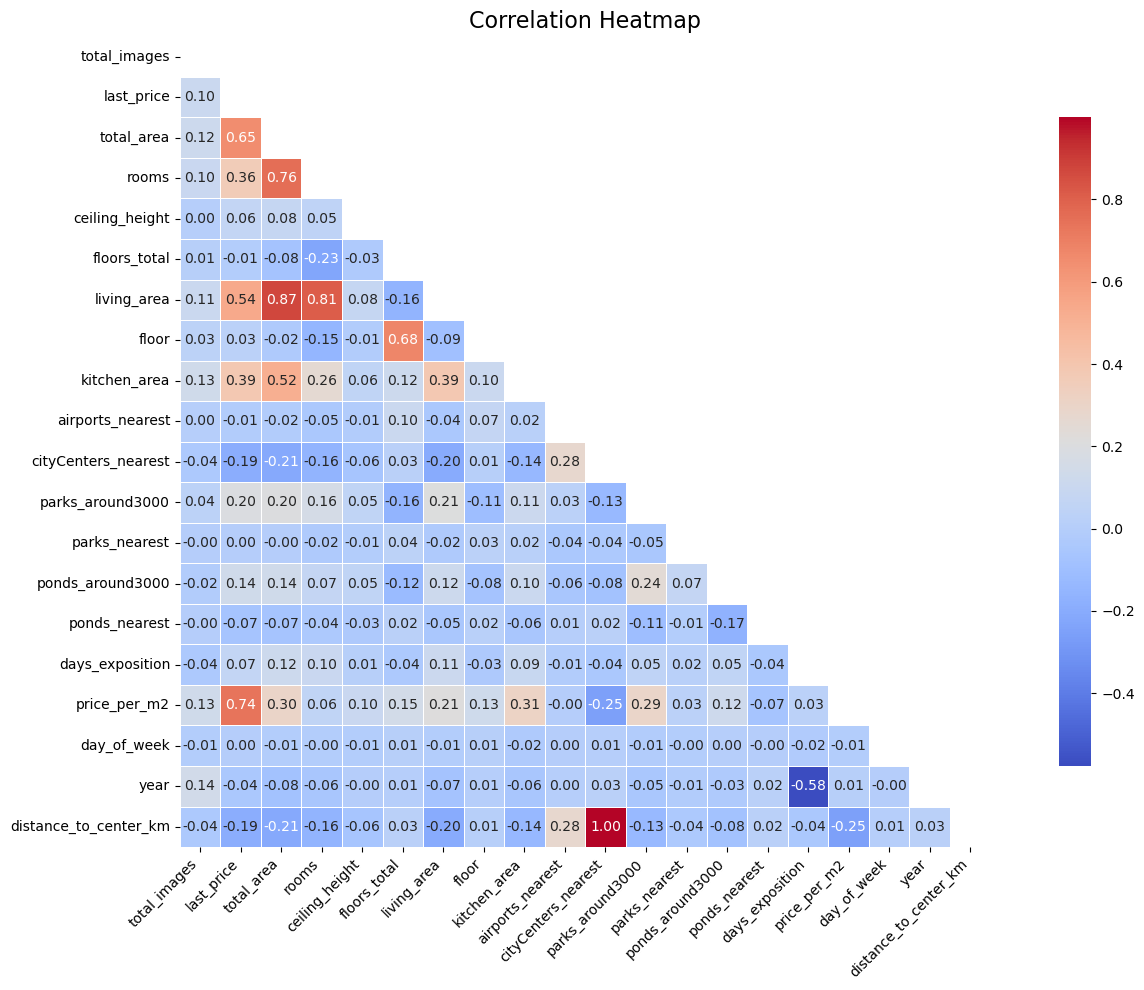

In [31]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_plot("correlation_heatmap")
plt.show()

**Key findings:**

- `living_area` and `total_area` exhibit a strong positive correlation (`0.88`), which is expected because larger living areas usually correspond to larger total areas.
- `price_per_m2` shows a moderate positive correlation with both `total_area` (`0.66`) and `last_price` (`0.57`), indicating that larger and more expensive properties also tend to command a higher price per square meter.
- Several variables display little substantive association with price. For example, the correlation between `balcony` and `price_per_m2` is close to zero (`0.01`), suggesting that balcony presence alone is not a major determinant of price per square meter.

The previously observed perfect negative correlation between `total_images` and `last_price` should be interpreted cautiously, as such a result is unlikely to reflect a genuine market relationship and may instead indicate a data or specification issue.

#### Distributional Analysis of Key Features

The derived variables and core property characteristics are visualized to examine their distributions and to identify broad structural patterns in the sample.

Saved: ../images/property_features_histograms.png


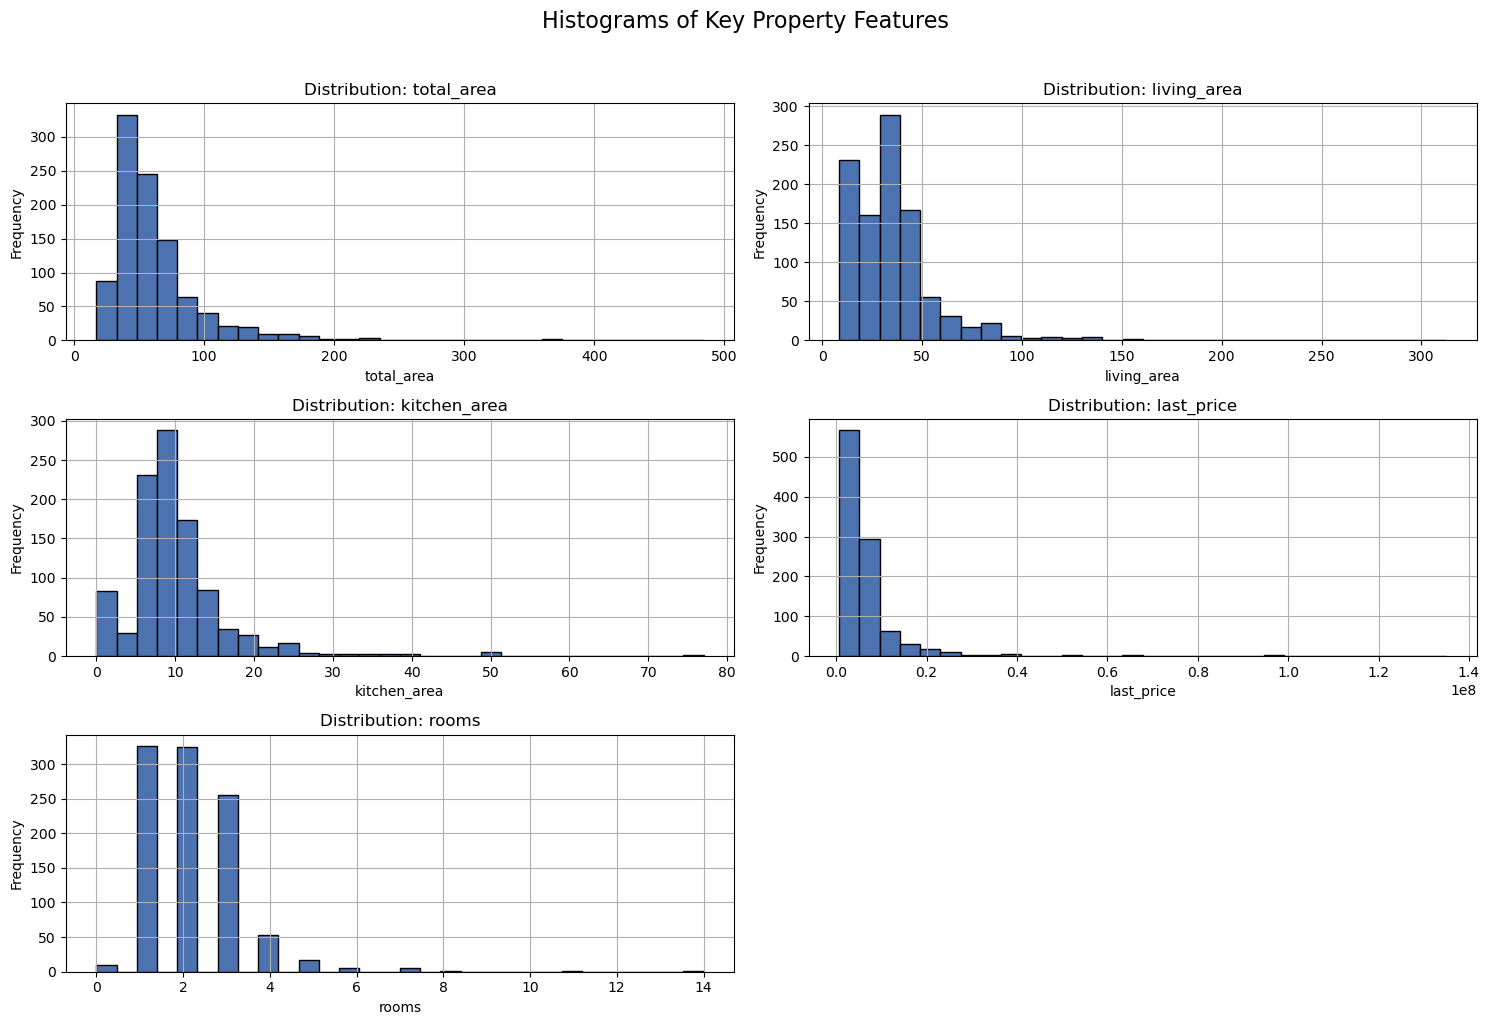

In [32]:
axes = data[:1000][['total_area', 'living_area', 'kitchen_area', 'last_price', 'rooms']].hist(
    figsize=(15, 10), bins=30, grid=True, color='#4C72B0', edgecolor='black'
)
for ax in axes.flatten():
    ax.set_ylabel('Frequency')
    ax.set_xlabel(ax.get_title())
    ax.set_title(f'Distribution: {ax.get_title()}')
plt.suptitle('Histograms of Key Property Features', fontsize=16, y=1.02)
plt.tight_layout()
save_plot("property_features_histograms")
plt.show()

Saved: ../images/price_distribution.png


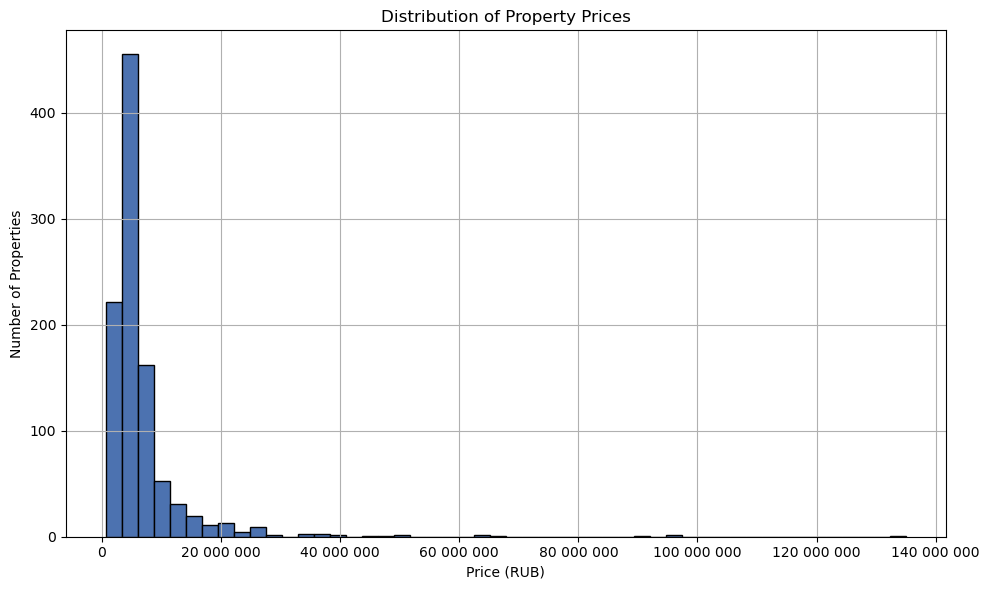

In [33]:
ax = data[:1000]['last_price'].plot.hist(bins=50, figsize=(10, 6), grid=True, color='#4C72B0', edgecolor='black')
ax.set_title('Distribution of Property Prices')
ax.set_xlabel('Price (RUB)')
ax.set_ylabel('Number of Properties')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("price_distribution")
plt.show()

This histogram presents the distribution of listing prices.

**Interpretation:**
- The distribution is strongly right-skewed, with the majority of observations concentrated in the lower price range and a substantial share of listings below 5 million rubles.
- The number of listings declines sharply at higher price levels, indicating that premium properties constitute a comparatively small segment of the sample.
- The long right tail is consistent with the typical structure of real estate price distributions, in which a limited number of high-value properties account for the extreme upper end.

**Conclusion:**
Most listings in the dataset fall within the lower and middle price segments. For a more refined analysis, it would be useful to examine price determinants separately across market segments.

Saved: ../images/rooms_distribution.png


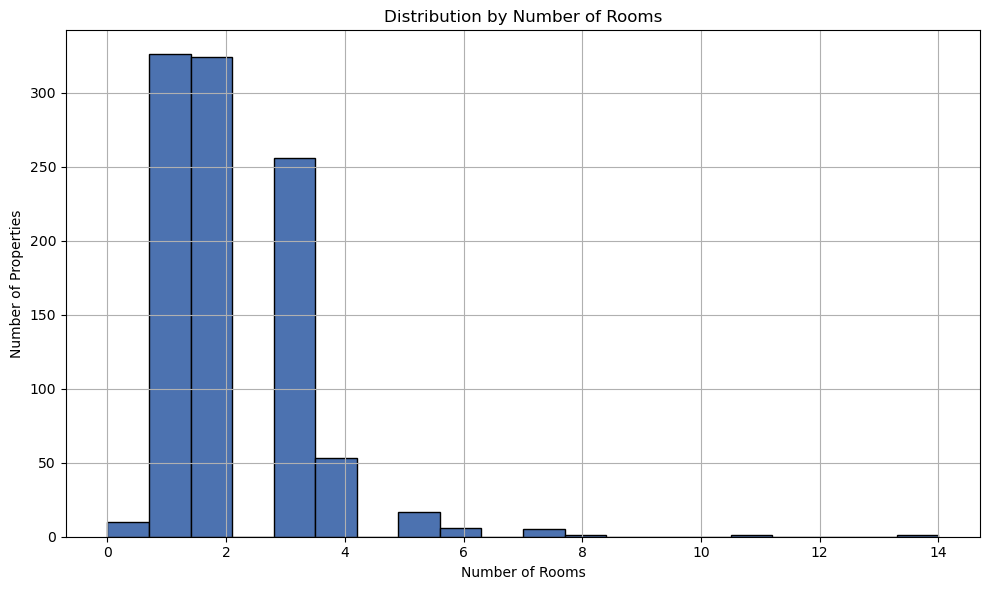

In [34]:
ax = data[:1000]['rooms'].plot.hist(bins=20, figsize=(10, 6), color='#4C72B0', edgecolor='black', grid=True)
ax.set_title('Distribution by Number of Rooms')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Number of Properties')
plt.tight_layout()
save_plot("rooms_distribution")
plt.show()

This histogram shows the distribution of properties by number of rooms.

**Interpretation:**
- Listings with 1 to 3 rooms clearly dominate the sample, indicating that smaller apartments make up the core of the observed market.
- Properties with more than 3 rooms are substantially less common, suggesting that larger apartments and houses represent a smaller segment of the dataset.
- The distribution is skewed toward smaller units, which is characteristic of an urban residential market.

**Conclusion:**
The market represented in the dataset is dominated by relatively compact apartments. Further analysis should examine how room count interacts with price, area, and location.

Saved: ../images/ceiling_height_distribution.png


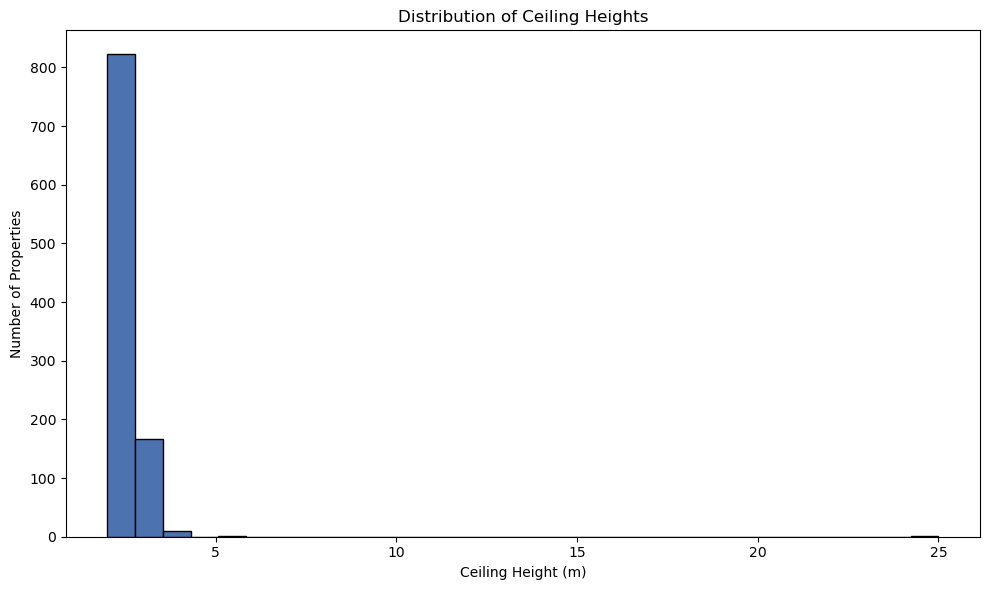

In [35]:
ax = data[:1000]['ceiling_height'].plot.hist(bins=30, figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Distribution of Ceiling Heights')
ax.set_xlabel('Ceiling Height (m)')
ax.set_ylabel('Number of Properties')
plt.tight_layout()
save_plot("ceiling_height_distribution")
plt.show()

Saved: ../images/ceiling_height_boxplot.png


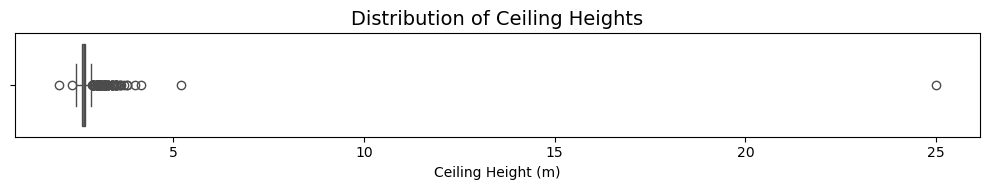

In [36]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=data[:1000]['ceiling_height'], color='#4C72B0')
plt.title('Distribution of Ceiling Heights', fontsize=14)
plt.xlabel('Ceiling Height (m)')
plt.tight_layout()
save_plot("ceiling_height_boxplot")
plt.show()

In [37]:
# Define reasonable bounds for ceiling height
lower_bound = 2.5  # minimum ceiling height
upper_bound = 5.5  # maximum ceiling height

In [38]:
data_cleaned = data[(data['ceiling_height'] >= lower_bound) & (data['ceiling_height'] <= upper_bound)]


In [39]:
# Use the IQR method to detect and remove outliers
Q1 = data_cleaned['ceiling_height'].quantile(0.25)
Q3 = data_cleaned['ceiling_height'].quantile(0.75)
IQR = Q3 - Q1

In [40]:
# Define outlier bounds
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

In [41]:
data_cleaned = data_cleaned[(data_cleaned['ceiling_height'] >= lower_bound_iqr) & (data_cleaned['ceiling_height'] <= upper_bound_iqr)]

Saved: ../images/ceiling_height_distribution_cleaned.png


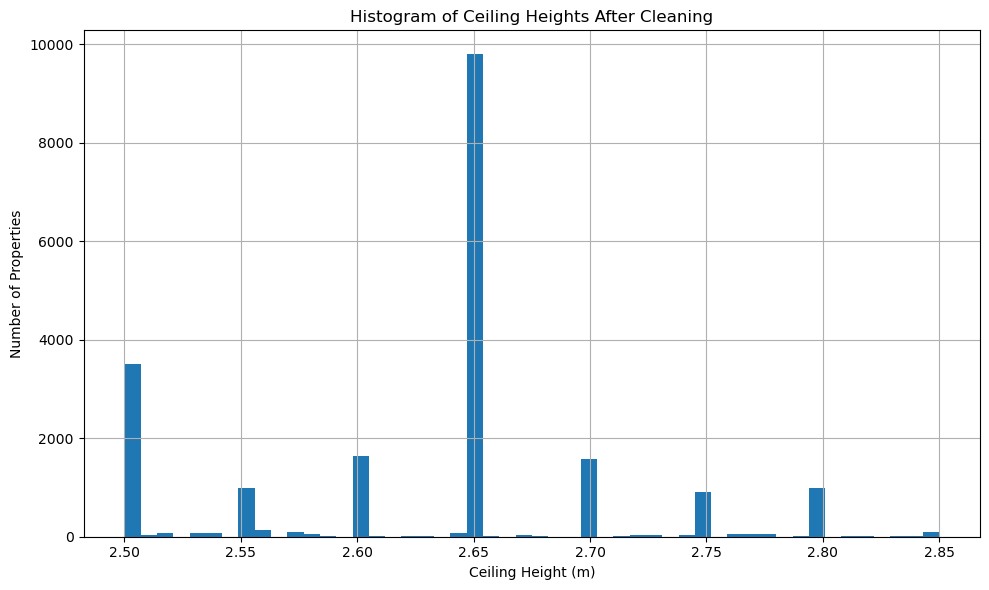

In [42]:
# Plot the histogram
data_cleaned['ceiling_height'].hist(bins=50, figsize=(10, 6))
plt.title('Histogram of Ceiling Heights After Cleaning')
plt.xlabel('Ceiling Height (m)')
plt.ylabel('Number of Properties')
save_plot("ceiling_height_distribution_cleaned")
plt.show()

This histogram summarizes the distribution of ceiling heights after data cleaning.

**Interpretation:**
- Most observations fall within a narrow interval between approximately 2.50 and 2.65 meters.
- A clear concentration around 2.55 meters suggests that this value is broadly characteristic of standard residential construction within the sample.
- After the removal of extreme values, the distribution becomes substantially more homogeneous.
- Ceiling heights above roughly 2.6 meters are comparatively uncommon, implying that apartments with atypically high ceilings represent a limited share of the market.

**Conclusion:**
The cleaned distribution indicates that standard ceiling heights dominate the dataset. A more detailed geographic breakdown may help determine whether ceiling height varies systematically across locations.

Saved: ../images/distance_to_city_center_distribution.png


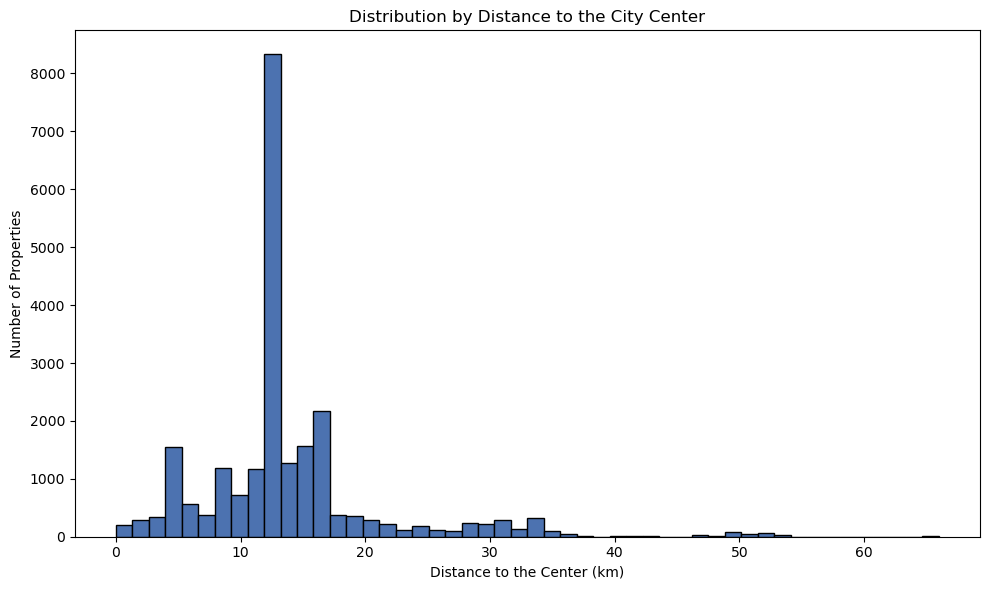

In [43]:
# Add the distance-to-center column in kilometers to data_no_outliers if it is missing
if 'distance_to_center_km' not in data_no_outliers.columns:
    data_no_outliers['distance_to_center_km'] = (data_no_outliers['cityCenters_nearest'] / 1000).round()

ax = data_no_outliers['distance_to_center_km'].plot.hist(bins=50, figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Distribution by Distance to the City Center')
ax.set_xlabel('Distance to the Center (km)')
ax.set_ylabel('Number of Properties')
plt.tight_layout()
save_plot("distance_to_city_center_distribution")
plt.show()

This histogram shows the distribution of properties by distance from the city center.

**Interpretation:**
- A substantial concentration of listings lies within 0 to 10 km of the center.
- Beyond this range, the number of properties decreases markedly.
- The pattern suggests that the sample is weighted toward properties located relatively close to the urban core, where both development density and demand are likely to be higher.

**Conclusion:**
Distance to the city center is not evenly distributed across the sample and should be treated as an important locational characteristic in the subsequent analysis.

Saved: ../images/floor_type_distribution.png


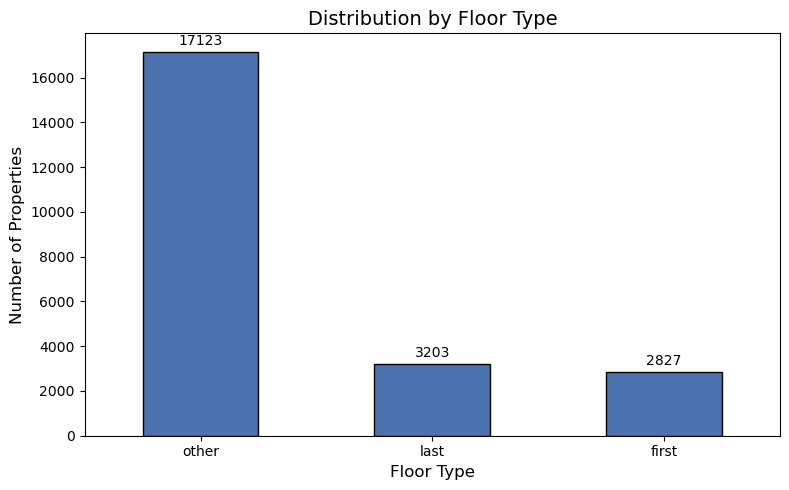

In [44]:
# Add the 'floor_type' column to data_no_outliers if it is missing
if 'floor_type' not in data_no_outliers.columns:
    data_no_outliers['floor_type'] = data_no_outliers.apply(
        lambda row: 'first' if row['floor'] == 1 else (
            'last' if row['floor'] == row['floors_total'] else 'other'),
        axis=1
    )

ax = data_no_outliers['floor_type'].value_counts().plot(
    kind='bar',
    figsize=(8, 5),
    color='#4C72B0',
    edgecolor='black'
)
ax.set_title('Distribution by Floor Type', fontsize=14)
ax.set_xlabel('Floor Type', fontsize=12)
ax.set_ylabel('Number of Properties', fontsize=12)
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
save_plot("floor_type_distribution")
plt.show()

**Interpretation:**
- The `other` floor category accounts for the majority of observations, indicating that most properties are located on intermediate floors.
- First-floor and top-floor apartments are less prevalent, which is structurally consistent with multi-story residential buildings.
- This distribution is also consistent with the expectation that intermediate floors represent the most common housing stock in apartment buildings.

**Conclusion:**
The sample is dominated by apartments on intermediate floors, while first-floor and top-floor units form smaller subgroups that may display distinct pricing behavior.

#### Examining the `days_exposition` Parameter (Time on Market)

Saved: ../images/days_exposition_distribution.png


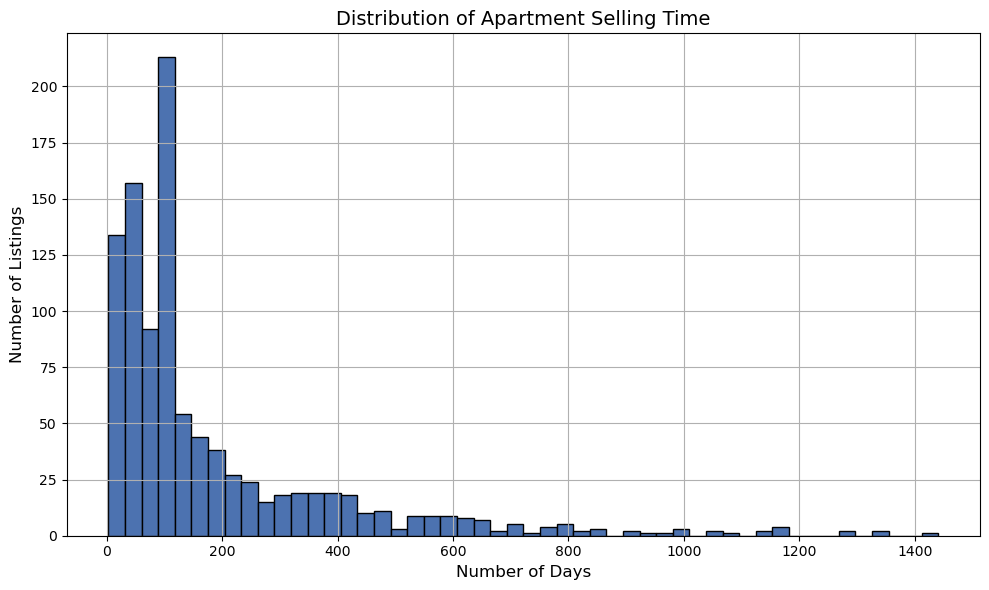

In [45]:
ax = data[:1000]['days_exposition'].plot.hist(bins=50, figsize=(10, 6), color='#4C72B0', edgecolor='black', grid=True)
ax.set_title('Distribution of Apartment Selling Time', fontsize=14)
ax.set_xlabel('Number of Days', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
save_plot("days_exposition_distribution")
plt.show()

**Interpretation:**
- Most apartments are sold relatively quickly, as indicated by the concentration of observations in the lower part of the distribution.
- The number of listings declines sharply as time on market increases.
- A small number of observations appear to represent unusually long selling periods.

**Conclusion:**
Extended time on market may indicate overpricing or property-specific disadvantages related to condition, layout, or location.

Mean and median values of `days_exposition`

In [46]:
mean_days = data['days_exposition'].mean()
median_days = data['days_exposition'].median()
mean_days, median_days

(np.float64(169.3476898318723), 95.0)

- The mean selling time is 168.7 days, indicating that, on average, apartments remain on the market for more than five months.
- The median selling time is 95 days, which implies that half of all properties are sold in less than this period.
- Listings sold within the first 30 days may be regarded as fast-moving properties.
- Listings remaining on the market for more than 100 days may be considered unusually slow sales and warrant additional examination.

#### Checking the Factors That Influence Price

##### Relationship Between Price and Total Area

Saved: ../images/price_vs_total_area.png


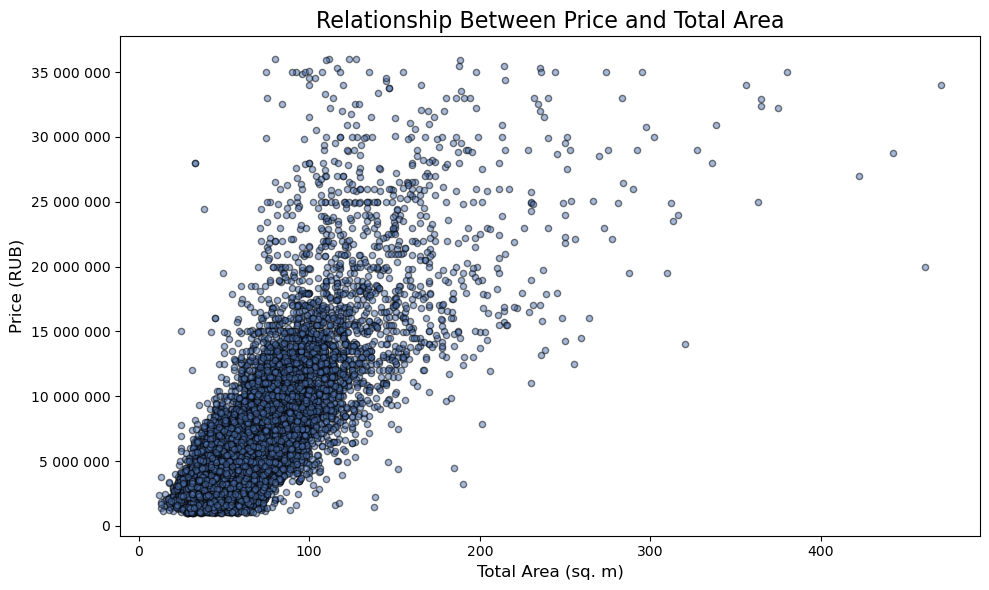

In [47]:
# Use data_no_outliers for a cleaner analysis to reduce the effect of extreme values
ax = data_no_outliers.plot.scatter(
    x='total_area',
    y='last_price',
    alpha=0.5,
    figsize=(10, 6),
    color='#4C72B0',
    edgecolor='black'
)
ax.set_title('Relationship Between Price and Total Area', fontsize=16)
ax.set_xlabel('Total Area (sq. m)', fontsize=12)
ax.set_ylabel('Price (RUB)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("price_vs_total_area")
plt.show()

Saved: ../images/price_vs_total_area_no_outliers.png


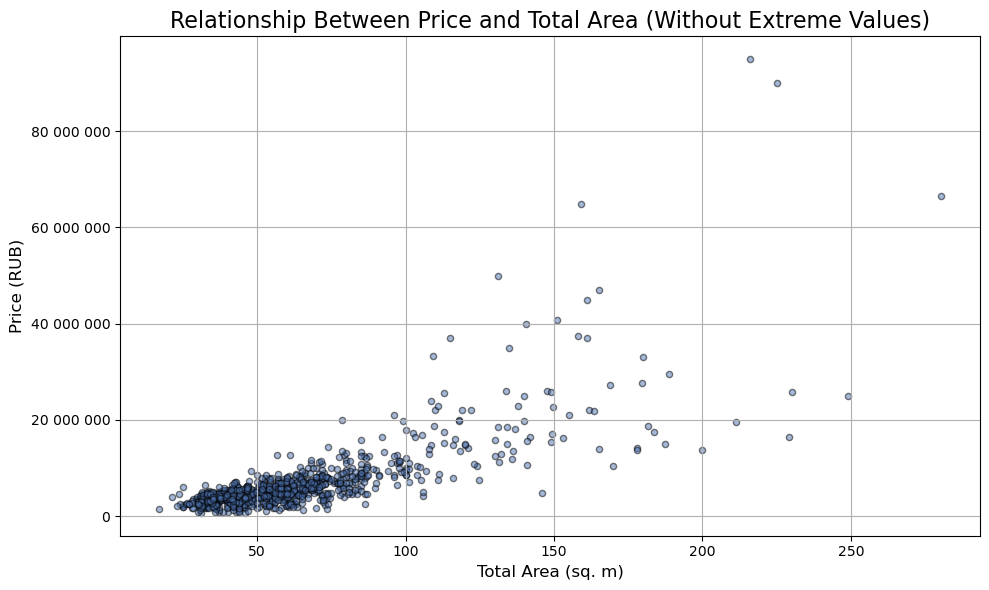

In [48]:
# Keep only apartments with an area below 300 sq. m
data_no_outliers = data[:1000][data[:1000]['total_area'] < 300]

ax = data_no_outliers.plot.scatter(
    x='total_area',
    y='last_price',
    alpha=0.5,
    figsize=(10, 6),
    color='#4C72B0',
    edgecolor='black',
    grid=True
)
ax.set_title('Relationship Between Price and Total Area (Without Extreme Values)', fontsize=16)
ax.set_xlabel('Total Area (sq. m)', fontsize=12)
ax.set_ylabel('Price (RUB)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("price_vs_total_area_no_outliers")
plt.show()

This scatter plot illustrates the relationship between price and total area after reducing the influence of extreme observations.

**Interpretation:**
- A clear positive association is observed: larger properties generally command higher prices.
- Most observations are concentrated in the lower-left portion of the chart, indicating that the sample is dominated by smaller, lower-priced properties.
- A limited number of high-priced observations remain even after filtering, suggesting residual heterogeneity within the upper segment of the market.

**Conclusion:**
Total area appears to be one of the principal determinants of price. The relationship is strong, although it is also likely mediated by location and property type.

##### Relationship Between Price and Number of Rooms

Saved: ../images/avg_price_by_rooms.png


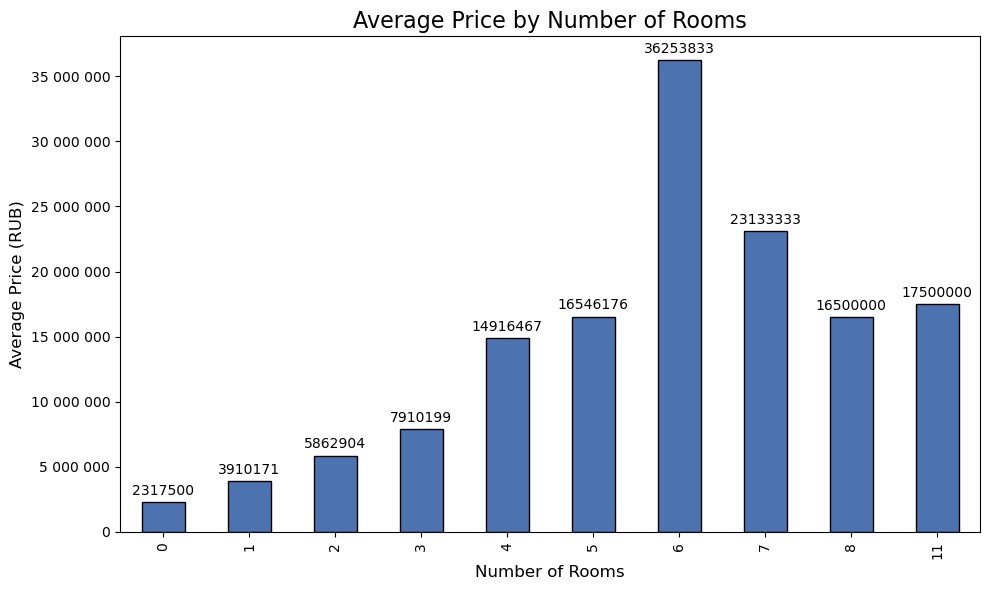

In [49]:
ax = data_no_outliers.groupby('rooms')['last_price'].mean().plot(
    kind='bar',
    figsize=(10, 6),
    color='#4C72B0',
    edgecolor='black'
)
ax.set_title('Average Price by Number of Rooms', fontsize=16)
ax.set_xlabel('Number of Rooms', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.tight_layout()
save_plot("avg_price_by_rooms")
plt.show()

Saved: ../images/avg_price_by_rooms_no_outliers.png


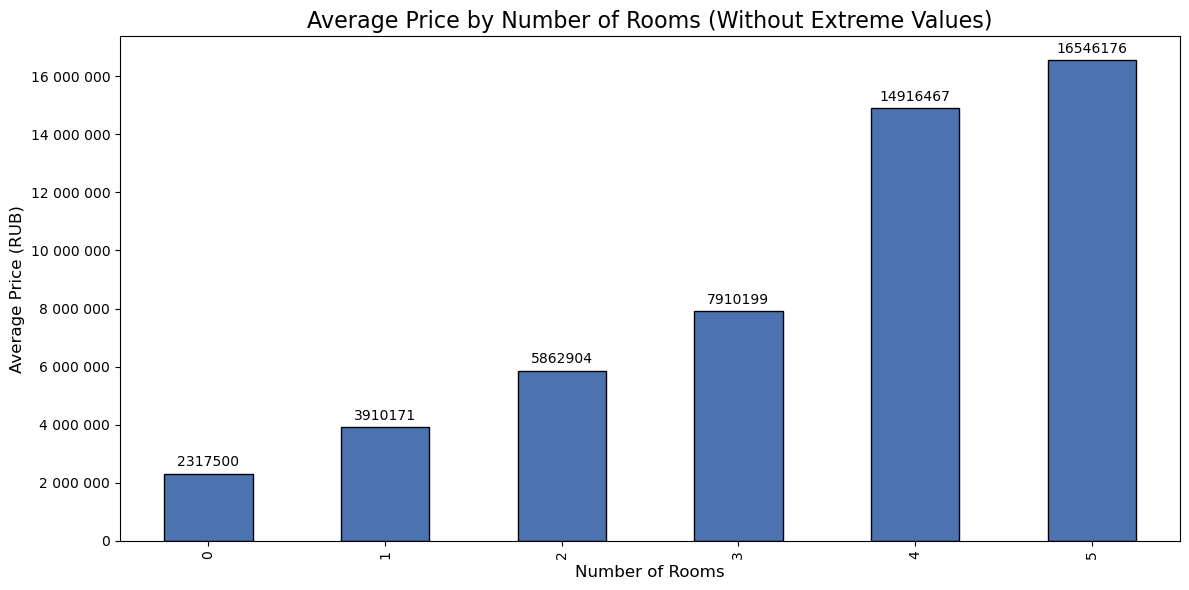

In [50]:
data_no_outliers_rooms = data_no_outliers[data_no_outliers['rooms'] <= 5]
ax = data_no_outliers_rooms.groupby('rooms')['last_price'].mean().plot(
    kind='bar',
    figsize=(12, 6),
    color='#4C72B0',
    edgecolor='black'
)
ax.set_title('Average Price by Number of Rooms (Without Extreme Values)', fontsize=16)
ax.set_xlabel('Number of Rooms', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.tight_layout()
save_plot("avg_price_by_rooms_no_outliers")
plt.show()

This chart presents the relationship between average property price and the number of rooms.

**Interpretation:**
- Average price increases with room count, which is consistent with standard market expectations.
- One- and two-room apartments are markedly less expensive than larger properties.
- The increase in average price becomes more pronounced for apartments with a greater number of rooms.

**Conclusion:**
Room count is an important correlate of price, although part of this relationship is likely explained by the close connection between room count and total area.

Saved: ../images/price_vs_kitchen_area_no_outliers.png


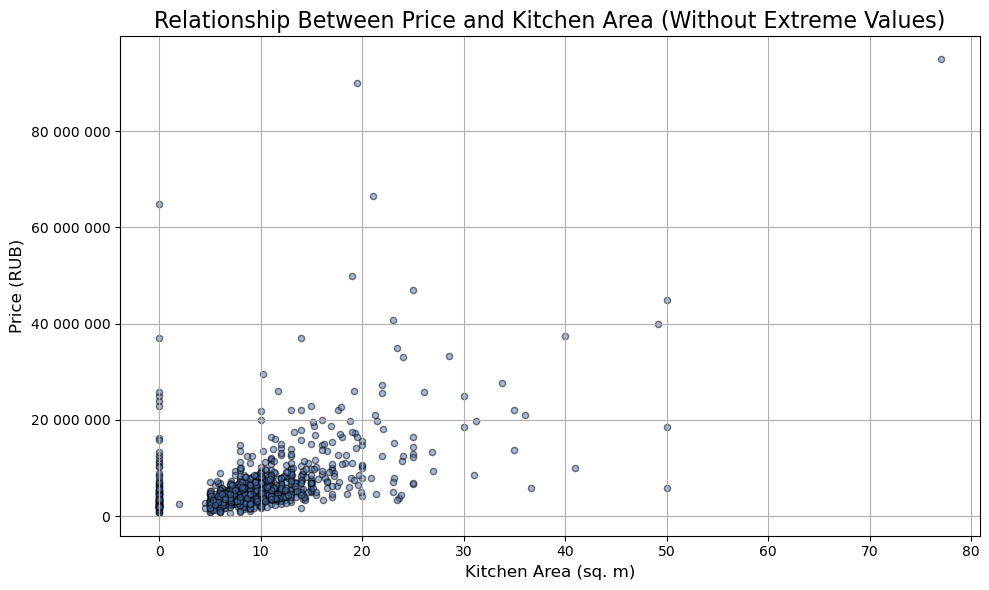

In [51]:
ax = data_no_outliers.plot.scatter(
    x='kitchen_area',
    y='last_price',
    alpha=0.5,
    figsize=(10, 6),
    color='#4C72B0',
    edgecolor='black',
    grid=True
)
ax.set_title('Relationship Between Price and Kitchen Area (Without Extreme Values)', fontsize=16)
ax.set_xlabel('Kitchen Area (sq. m)', fontsize=12)
ax.set_ylabel('Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("price_vs_kitchen_area_no_outliers")
plt.show()

This scatter plot shows the relationship between kitchen area and property price.

**Interpretation:**
- No strong linear relationship is evident.
- Properties with similar kitchen areas may differ substantially in price.
- Although larger kitchens are more common in larger dwellings, kitchen area alone does not appear to be a decisive pricing factor.

**Conclusion:**
Kitchen area has limited explanatory power when considered in isolation. Broader structural characteristics, such as total area, location, and property segment, appear to play a more substantial role in price formation.

##### Relationship Between Price and Floor Type

Saved: ../images/avg_price_by_floor_type.png


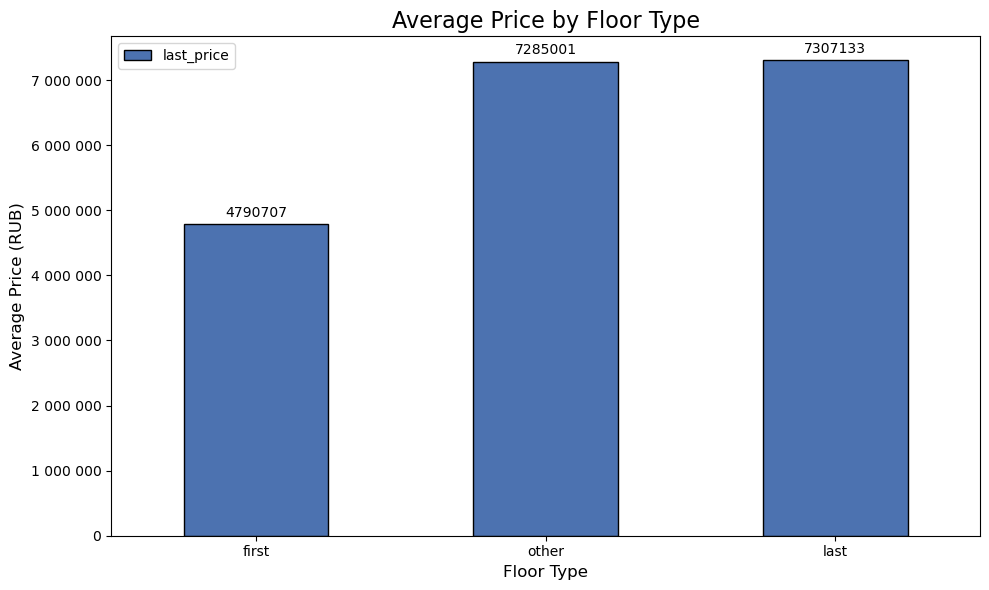

In [52]:
# Check whether the 'floor_type' column exists; create it if necessary
if 'floor_type' not in data[:1000].columns:
    data[:1000]['floor_type'] = data[:1000].apply(
        lambda row: 'first' if row['floor'] == 1 else (
            'last' if row['floor'] == row['floors_total'] else 'other'),
        axis=1
    )

pivot_floor_type = data[:1000].pivot_table(values='last_price', index='floor_type', aggfunc='mean').sort_values('last_price')
ax = pivot_floor_type.plot(kind='bar', figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Average Price by Floor Type', fontsize=16)
ax.set_xlabel('Floor Type', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
save_plot("avg_price_by_floor_type")
plt.show()

This chart reports average property price by floor category.

**Interpretation:**
- Apartments on the first and last floors exhibit similar average prices and are somewhat less expensive than apartments on intermediate floors.
- Properties classified as `other`, that is, those on intermediate floors, have the highest average price.
- This pattern is consistent with the common market perception that intermediate floors are more desirable than first-floor or top-floor units.

**Conclusion:**
Floor category appears to influence price, although its effect is weaker than that of major structural and locational factors.

##### Relationship Between Price and Distance to the Nearest Park

Saved: ../images/avg_price_vs_distance_to_nearest_park.png


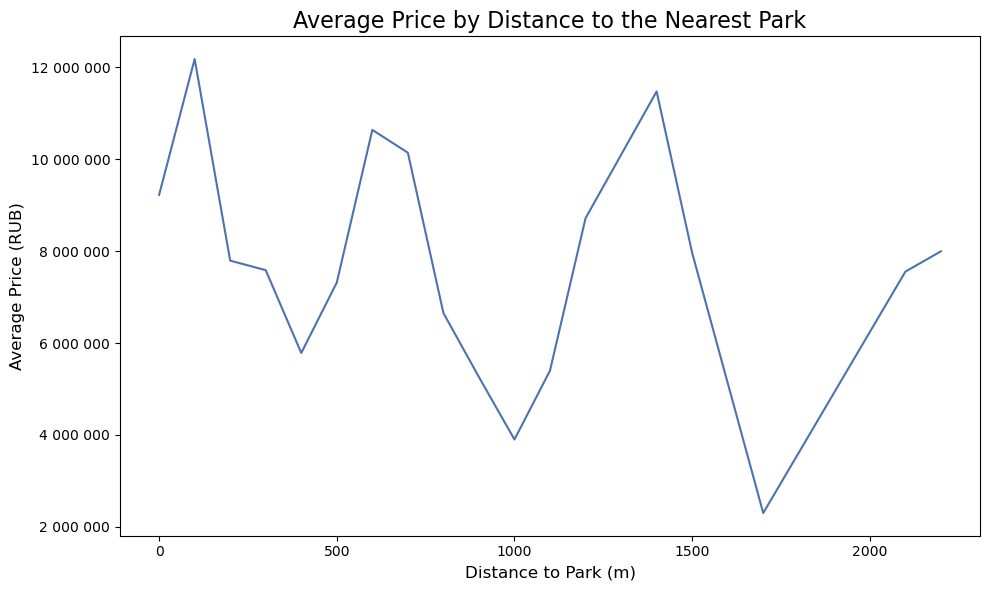

In [53]:
# Group by rounded distance to the park (100-meter bins) for smoothing
grouped = data_no_outliers.groupby((data_no_outliers['parks_nearest'] // 100) * 100)['last_price'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
grouped.plot(ax=ax, color='#4C72B0')
ax.set_title('Average Price by Distance to the Nearest Park', fontsize=16)
ax.set_xlabel('Distance to Park (m)', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("avg_price_vs_distance_to_nearest_park")
plt.show()

This chart presents the relationship between average price and distance to the nearest park.

**Interpretation:**
- The relationship is not linear.
- Prices fluctuate considerably at shorter distances, which may suggest that proximity to a park increases desirability in certain locations.
- At greater distances, variation remains substantial, implying that the effect of park proximity is conditional on broader locational and structural factors.

**Conclusion:**
Distance to the nearest park may contribute to price differentiation, but its effect appears secondary and context-dependent.

##### Relationship Between Price and Distance to the Center

Saved: ../images/avg_price_vs_distance_to_city_center.png


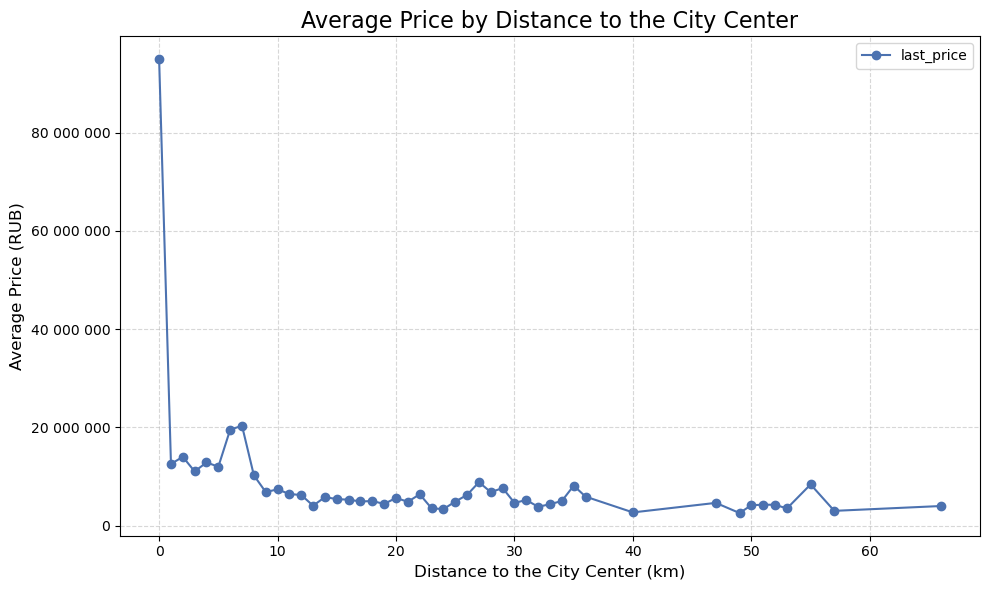

In [54]:
# Add the distance-to-center column in kilometers to data_no_outliers if it is missing
if 'distance_to_center_km' not in data_no_outliers.columns:
    data_no_outliers['distance_to_center_km'] = (data_no_outliers['cityCenters_nearest'] / 1000).round()

# Average price by distance to the center (without extreme values)
pivot_distance_to_center = data_no_outliers.pivot_table(
    values='last_price',
    index='distance_to_center_km',
    aggfunc='mean'
).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
pivot_distance_to_center.plot(ax=ax, color='#4C72B0', marker='o')
ax.set_title('Average Price by Distance to the City Center', fontsize=16)
ax.set_xlabel('Distance to the City Center (km)', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
save_plot("avg_price_vs_distance_to_city_center")
plt.show()

This chart shows how average property price varies with distance from the city center.

**Interpretation:**
- Average price generally declines as distance from the center increases.
- The curve becomes less smooth at greater distances, which may reflect heterogeneity across individual localities.
- The sharp decline outside the central zone suggests that centrality is one of the key locational determinants of price.

**Conclusion:**
Distance to the city center exerts a substantial influence on price, although the relationship is moderated by neighborhood-specific characteristics.

##### Average Price per Square Meter by Locality

To understand how location affects price, we calculated the average price per square meter for each locality. Below are the top 10 localities with the highest average price per square meter.

Saved: ../images/avg_price_per_m2_top_locations.png


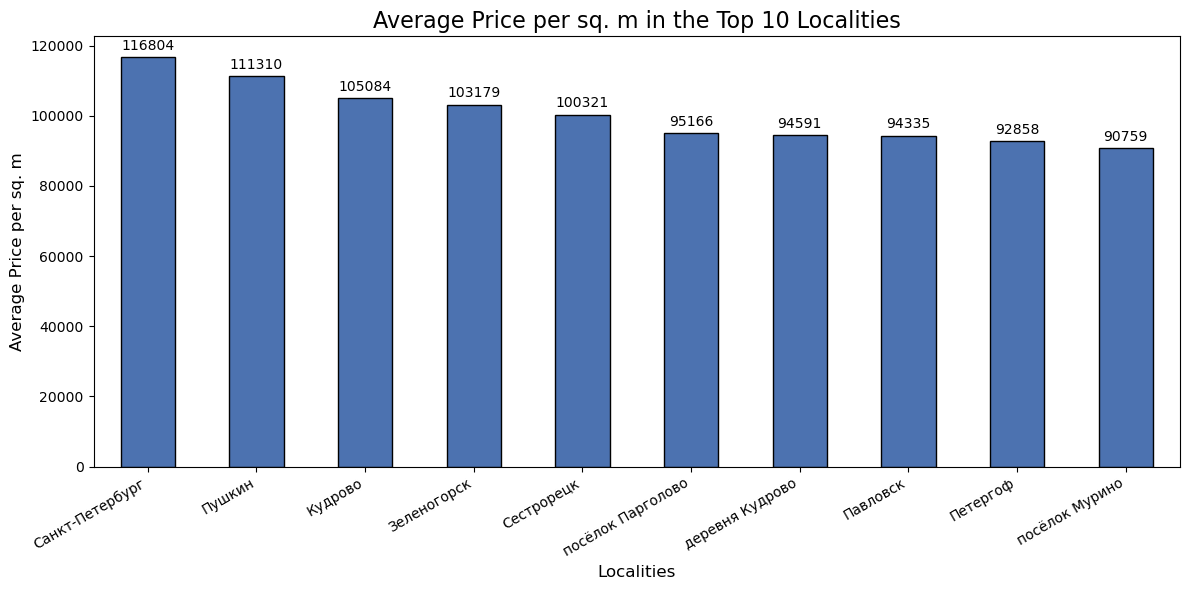

In [55]:
top_10_localities = data[:1000].groupby('locality_name')['price_per_m2'].mean().sort_values(ascending=False).head(10)

ax = top_10_localities.plot(kind='bar', figsize=(12, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Average Price per sq. m in the Top 10 Localities', fontsize=16)
ax.set_xlabel('Localities', fontsize=12)
ax.set_ylabel('Average Price per sq. m', fontsize=12)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_plot("avg_price_per_m2_top_locations")
plt.show()

**Analytical observations:**

1. Lisiy Nos occupies the highest position in terms of average price per square meter, likely reflecting a combination of environmental quality, prestige, and limited supply.
2. Zelenogorsk also demonstrates a high average price per square meter, which is consistent with its reputation as a desirable suburban location.
3. Saint Petersburg, as expected, remains among the most expensive markets in the sample because of sustained demand and dense urban development.
4. Several smaller localities also rank highly, suggesting that premium pricing is not limited to the metropolitan core.

**Conclusion:**
The results indicate that location is a major determinant of price per square meter. Prestigious suburban areas can match or exceed Saint Petersburg in unit price, whereas more remote or less attractive localities tend to remain more affordable.

##### Relationship Between Price and Distance to the City Center in Saint Petersburg

To examine in more detail how distance from the center affects price, we grouped properties by distance to the city center and calculated the average price per square meter.

Saved: ../images/avg_price_per_m2_vs_distance_to_spb_center.png


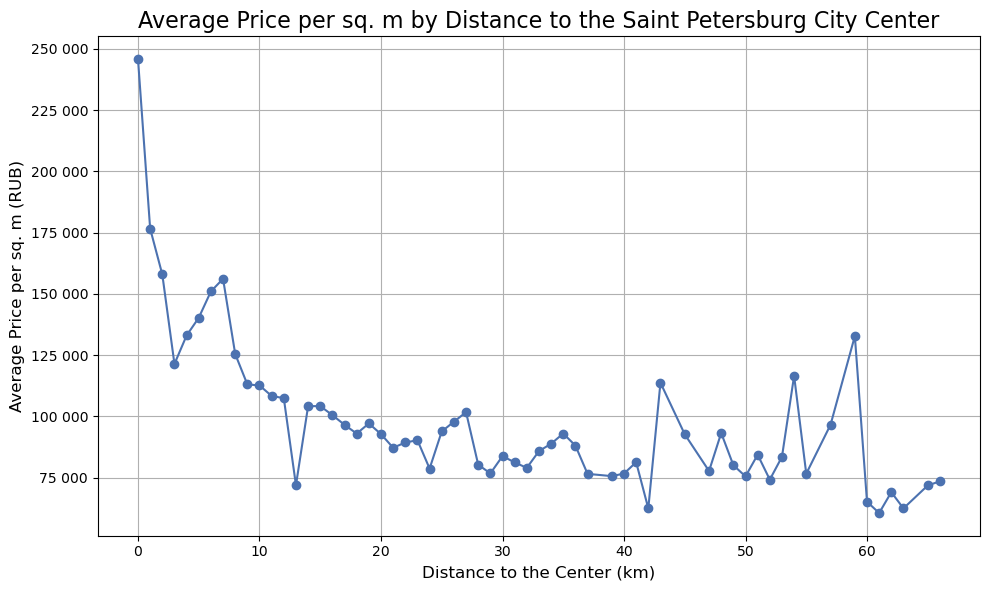

In [56]:
# Add the column if it is missing
if 'distance_to_center_km' not in data.columns:
    data['distance_to_center_km'] = (data['cityCenters_nearest'] / 1000).round()

ax = data.groupby('distance_to_center_km')['price_per_m2'].mean().plot(
    figsize=(10, 6),
    marker='o',
    color='#4C72B0',
    grid=True
)
ax.set_title('Average Price per sq. m by Distance to the Saint Petersburg City Center', fontsize=16)
ax.set_xlabel('Distance to the Center (km)', fontsize=12)
ax.set_ylabel('Average Price per sq. m (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
plt.tight_layout()
save_plot("avg_price_per_m2_vs_distance_to_spb_center")
plt.show()

**Interpretation:**
1. Average price per square meter declines noticeably within the first several kilometers from the city center.
2. At greater distances, the series becomes more stable.
3. A local increase farther from the center may reflect the presence of high-value suburban locations or a limited number of atypical observations.

**Conclusion:**
Within Saint Petersburg, price per square meter is strongly associated with centrality. Properties closest to the center occupy the upper end of the market, whereas prices tend to level off at greater distances.

##### Relationship Between Price and Day of the Week

Saved: ../images/avg_price_by_weekday.png


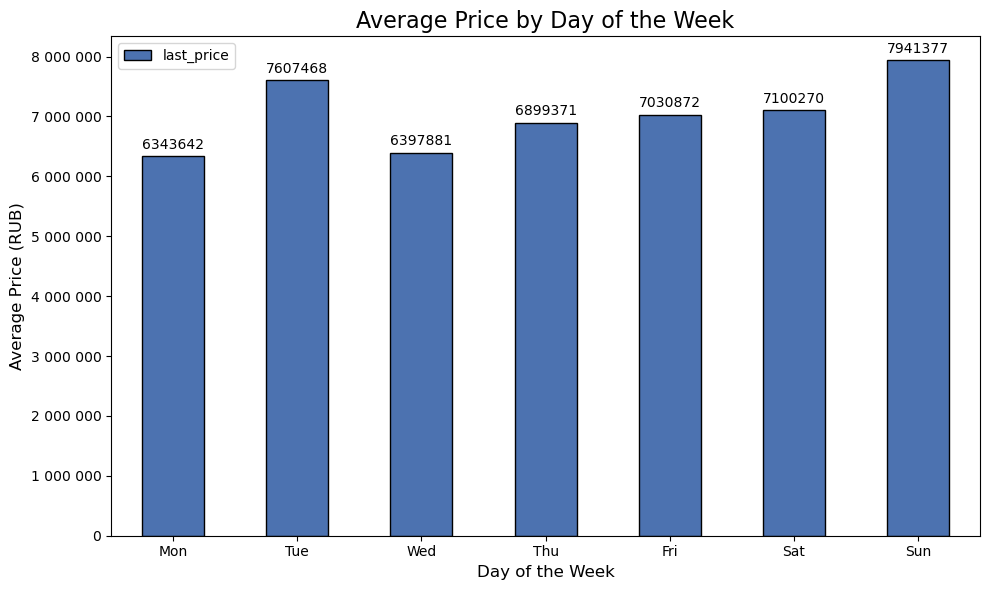

In [57]:
day = data[:1000].pivot_table(index='day_of_week', values='last_price', aggfunc='mean').reindex(range(7))
ax = day.plot(kind='bar', figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Average Price by Day of the Week', fontsize=16)
ax.set_xlabel('Day of the Week', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.tight_layout()
save_plot("avg_price_by_weekday")
plt.show()

Average prices vary only slightly across the days of the week. This suggests that the day on which a listing is published is not a major determinant of property price in the present dataset.

##### Relationship Between Price and Month

Saved: ../images/avg_price_by_month.png


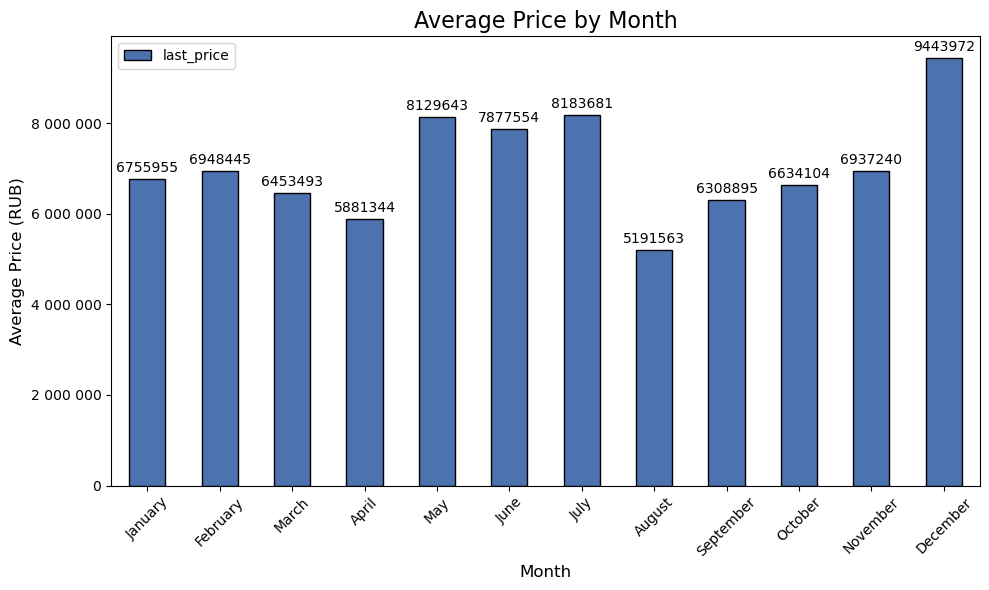

In [58]:
month = data[:1000].pivot_table(index=data[:1000]['first_day_exposition'].dt.month, values='last_price', aggfunc='mean').reindex(range(1, 13))
ax = month.plot(kind='bar', figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Average Price by Month', fontsize=16)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.set_xticks(range(12))
ax.set_xticklabels(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.tight_layout()
save_plot("avg_price_by_month")
plt.show()

Average price remains relatively stable across months, with no pronounced seasonal fluctuations. Within this dataset, month of publication appears to have little effect on price in this dataset.

##### Relationship Between Price and Year

Saved: ../images/avg_price_by_year.png


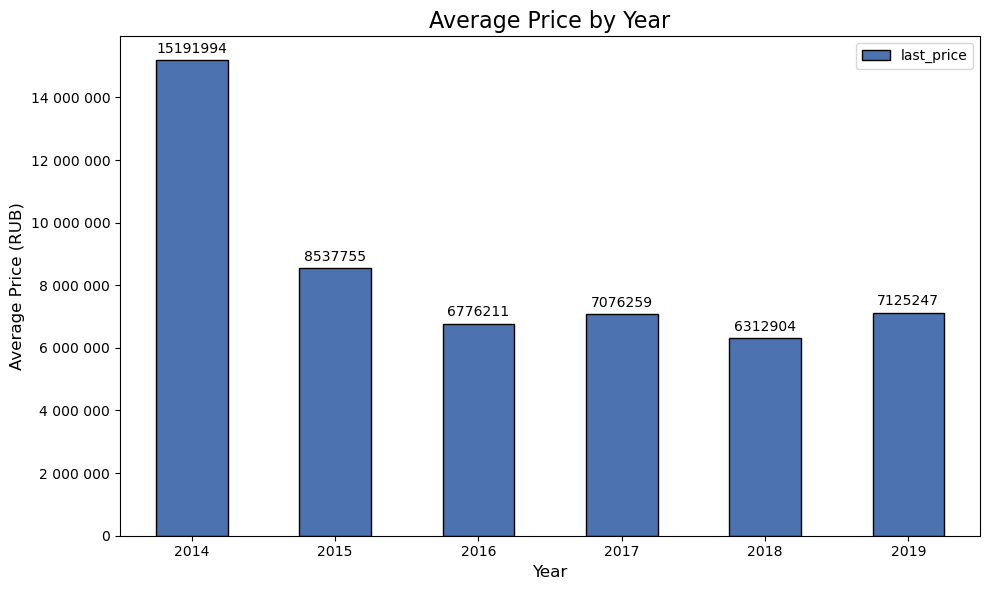

In [59]:
year = data[:1000].pivot_table(index='year', values='last_price', aggfunc='mean')
ax = year.plot(kind='bar', figsize=(10, 6), color='#4C72B0', edgecolor='black')
ax.set_title('Average Price by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Price (RUB)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
save_plot("avg_price_by_year")
plt.show()

The annual dynamics indicate a pronounced price peak in 2014, followed by a decline through 2017 and subsequent stabilization with modest fluctuations through 2019. This pattern may reflect broader macroeconomic conditions or cyclical changes in the housing market.

#### Overall Conclusion

This study proceeded through the principal stages of exploratory data analysis in a structured manner.

1. The dataset was inspected and cleaned, with particular attention to missing values, data types, and duplicate entries.
2. Additional analytical variables were constructed, including price per square meter, distance to the city center, and floor category.
3. The analysis then examined how price varies with structural characteristics, spatial position, and temporal factors.
4. Distributional plots and relationship charts were used to identify patterns, detect outliers, and evaluate the relative importance of different variables.

The main conclusions are as follows:

1. **Association between features and price:**
Price is most strongly associated with total area, living area, price per square meter, number of rooms, and kitchen area. Temporal variables and floor category appear to play a more limited role.

2. **Distributional properties of the data:**
Most apartments are sold relatively quickly, whereas unusually long selling periods are comparatively rare and may indicate atypical listings. The dataset also contains extreme observations, particularly in the price variable.

3. **Role of property size:**
Property size is one of the central determinants of price. Larger apartments tend to be more expensive, both in absolute terms and, to a lesser extent, in unit-value terms.

4. **Role of room count:**
The number of rooms is positively associated with price, although part of this effect reflects its close relationship with overall size.

5. **Role of location:**
Location is one of the strongest determinants of value. Properties nearer to the center of Saint Petersburg tend to be more expensive, while certain suburban localities also achieve high price levels because of prestige, environmental quality, or local demand conditions.

6. **Overall drivers of price:**
The evidence indicates that the strongest contributors to price are property size and location. Other factors, such as floor category and nearby amenities, may influence value, but their effects appear weaker and more context-specific.

**Final conclusion:**
The analysis provides a coherent overview of the principal factors associated with real estate prices in the dataset. In particular, area, location, and room count emerge as the most influential variables. These results can serve as a foundation for subsequent modeling and for the development of tools aimed at detecting anomalous property listings.